In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from PropGen.GAN.GAN import GAN
from PropGen.BladeDictGenerator import generate_blade_dict
from FastBEMT.Utils import LowFidelityParameters
from FastBEMT.Propeller import Propeller
import scienceplots

plt.style.use(['science', 'no-latex'])

In [2]:
gan = GAN(latent_dim=4, noise_dim=0)
gan.load_checkpoint('N:/Teams/Groups/ThermalSim/Projects/Public/BAZL Propeller/AirfoilGAN Models/WGAN_LCR1/latent4_noise0/checkpoint_50000.pth')

r_hub = 0.02794
r_tip = 0.127
n_blades = 2

# Random root and tip latent vectors (same for all parametrizations)
np.random.seed(42)
root_latent = np.random.randn(gan.latent_dim)
tip_latent = np.random.randn(gan.latent_dim)

Successfully loaded checkpoint from step 50000


In [4]:
import time

x = np.array([5.02943264e-01, 6.64959385e-02, 7.66835209e-01, 2.52184857e-01,
        6.21649488e-01, 2.65749249e-01, 6.70931606e-01, 1.01458536e-01,
        2.96178889e-02, 7.12442732e+00, 9.26211526e-03, 1.88402053e-02,
        2.70497989e+01, 4.59103735e-01, 7.91479577e+00])

n_sections_range = [5, 10, 15, 20, 30, 40, 50, 75, 100]
thrust_values = []
torque_values = []
time_values = []

print('Running convergence analysis...')
for n_sec in n_sections_range:
    print(f'  n_sections = {n_sec}', end='', flush=True)

    blade_dict = generate_blade_dict(
        x=x,
        parametrization='parametric',
        gan=gan,
        r_hub=r_hub,
        r_tip=r_tip,
        n_sections=n_sec,
        n_blades=n_blades
    )
    
    # Create propeller and run BEMT
    params = LowFidelityParameters(
        a_inf=343,
        rho=1.225,
        mu=1.81e-5,
        n_blades=int(blade_dict['n_blades']),
        p_ref=2e-5,
        revolutions=5,
        num_obs_times_per_rev=100,
        device='cpu',
    )
    
    propeller = Propeller(
        geometry=blade_dict,
        params=params,
    )
    
    t_start = time.time()
    propeller.run_bemt(rpm=7000,v_inf=0)
    T, Q, _, _, _ = propeller.compute_total_forces()
    t_end = time.time()
    elapsed_time = t_end - t_start
    
    thrust_values.append(T)
    torque_values.append(Q)
    time_values.append(elapsed_time)
    print(f' -> T = {T:.3f} N, Q = {Q:.3f} N·m, t = {elapsed_time:.3f} s')

print('Done!')

Running convergence analysis...
  n_sections = 5

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:119: RuntimeWarning: divide by zero encountered in divide
  f_tip = n_blades * (self.prop_radius - r) / (2 * r * np.abs(sin_phi))
C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:120: RuntimeWarning: divide by zero encountered in divide
  f_hub = n_blades * (r - self.hub_radius) / (2 * r * np.abs(sin_phi))


 -> T = 7.404 N, Q = 0.109 N·m, t = 0.176 s
  n_sections = 10

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:119: RuntimeWarning: divide by zero encountered in divide
  f_tip = n_blades * (self.prop_radius - r) / (2 * r * np.abs(sin_phi))
C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:120: RuntimeWarning: divide by zero encountered in divide
  f_hub = n_blades * (r - self.hub_radius) / (2 * r * np.abs(sin_phi))


 -> T = 7.902 N, Q = 0.115 N·m, t = 0.233 s
  n_sections = 15

...

 -> T = 8.055 N, Q = 0.116 N·m, t = 1.227 s
  n_sections = 75

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:119: RuntimeWarning: divide by zero encountered in divide
  f_tip = n_blades * (self.prop_radius - r) / (2 * r * np.abs(sin_phi))
C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:120: RuntimeWarning: divide by zero encountered in divide
  f_hub = n_blades * (r - self.hub_radius) / (2 * r * np.abs(sin_phi))


 -> T = 8.060 N, Q = 0.116 N·m, t = 1.793 s
  n_sections = 100

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:119: RuntimeWarning: divide by zero encountered in divide
  f_tip = n_blades * (self.prop_radius - r) / (2 * r * np.abs(sin_phi))
C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:120: RuntimeWarning: divide by zero encountered in divide
  f_hub = n_blades * (r - self.hub_radius) / (2 * r * np.abs(sin_phi))


 -> T = 8.061 N, Q = 0.116 N·m, t = 2.362 s
Done!


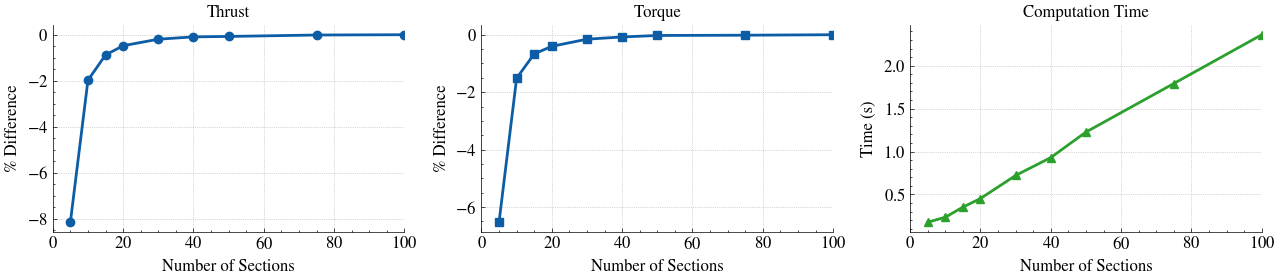


--- Summary ---
n_sections: [5, 10, 15, 20, 30, 40, 50, 75, 100]
Thrust (N):        [7.40418947 7.90150481 7.98999112 8.02228986 8.04509388 8.05334135
 8.05483206 8.05981164 8.06082776]
Thrust % diff:     [-8.14604038 -1.97650857 -0.87877618 -0.47808853 -0.1951893  -0.0928739
 -0.0743807  -0.01260556  0.        ]
Torque (N·m):      [0.10879128 0.11462224 0.11560825 0.11591491 0.11620377 0.11629407
 0.11635455 0.11636522 0.11638496]
Torque % diff:     [-6.52462028 -1.51455731 -0.66736059 -0.40387126 -0.15567955 -0.07809262
 -0.02613264 -0.01696479  0.        ]
Time (s):          [0.17566657 0.23324871 0.35118437 0.45157814 0.7206924  0.92903066
 1.2267189  1.79281759 2.36183167]


In [5]:
# Plot convergence
fig, axes = plt.subplots(1, 3, figsize=(13, 3))

# Calculate reference values at 100 sections (last value)
thrust_ref = thrust_values[-1]
torque_ref = torque_values[-1]

# Calculate percentage differences
thrust_pct = (np.array(thrust_values) - thrust_ref) / thrust_ref * 100
torque_pct = (np.array(torque_values) - torque_ref) / torque_ref * 100

# Thrust convergence
ax = axes[0]
ax.plot(n_sections_range, thrust_pct, 'o-', linewidth=2, markersize=6)
ax.set_xlabel('Number of Sections', fontsize=12)
ax.set_ylabel('% Difference', fontsize=12)
ax.set_title('Thrust', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=1, linestyle=':')
ax.set_xlim(0, 100)

# Torque convergence
ax = axes[1]
ax.plot(n_sections_range, torque_pct, 's-', linewidth=2, markersize=6)
ax.set_xlabel('Number of Sections', fontsize=12)
ax.set_ylabel('% Difference', fontsize=12)
ax.set_title('Torque', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=1, linestyle=':')
ax.set_xlim(0, 100)

# Computation time
ax = axes[2]
ax.plot(n_sections_range, time_values, '^-', linewidth=2, markersize=6, color='tab:green')
ax.set_xlabel('Number of Sections', fontsize=12)
ax.set_ylabel('Time (s)', fontsize=12)
ax.set_title('Computation Time', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.tick_params(labelsize=12)
ax.grid(True, alpha=1, linestyle=':')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('../Figures/Validation/section_convergence.png', dpi=200)
plt.show()

# Print summary
print('\n--- Summary ---')
print(f'n_sections: {n_sections_range}')
print(f'Thrust (N):        {np.array(thrust_values)}')
print(f'Thrust % diff:     {thrust_pct}')
print(f'Torque (N·m):      {np.array(torque_values)}')
print(f'Torque % diff:     {torque_pct}')
print(f'Time (s):          {np.array(time_values)}')